# 119: Kmerseek-Only Ortholog Pairs — Biological Characterization

Characterize the ~770 ortholog pairs that **Kmerseek finds but OrthoFinder misses**.

- **Kmerseek TPs (raw p < 0.05)**: pairs with Poisson p < 0.05 AND true MGI ortholog
- **OrthoFinder TPs**: pairs in OrthoFinder predictions AND true MGI ortholog
- **Kmerseek-only**: Kmerseek TPs NOT recovered by OrthoFinder

In [3]:
%pip install gprofiler-official requests -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy.stats import poisson, mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests
from gprofiler import GProfiler

sns.set_style("whitegrid")

DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
OF_DIR = Path("/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03")

KSIZE = 24
ALPHA = 0.05

KMERSEEK_TSV = DATA_DIR / f"ortholog_evaluation.hp.k{KSIZE}.tsv.gz"
MGI_FILE = DATA_DIR / "HOM_MouseHumanSequence.rpt.gz"
OF_ORTHOLOGS_TSV = (
    OF_DIR
    / "Orthologues/Orthologues_gencode.v49.pc_translations"
    / "gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv"
)

PREFIX = "119_"
print("Config OK")

Config OK


## Cell 1: Data Loading — Identify Kmerseek-Only Pairs

In [5]:
# --- MGI Ground Truth ---
mgi_raw = pl.read_csv(
    str(MGI_FILE),
    separator="\t",
    infer_schema_length=10000,
    null_values=["", "NA"],
)
print(f"MGI raw shape: {mgi_raw.shape}")

human_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "human_symbol"})
)
mouse_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "mouse_symbol"})
)

mgi_pairs = human_rows.join(mouse_rows, on="DB Class Key", how="inner").with_columns(
    [
        pl.col("human_symbol").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_symbol").str.to_uppercase().alias("mouse_upper"),
    ]
)

mgi_ortholog_set = set(
    zip(mgi_pairs["human_upper"].to_list(), mgi_pairs["mouse_upper"].to_list())
)
print(f"MGI ortholog pairs: {len(mgi_ortholog_set):,}")

MGI raw shape: (46522, 13)
MGI ortholog pairs: 24,584


In [6]:
# --- Kmerseek Data (load with Polars) ---
USECOLS = [
    "query_name",
    "target_name",
    "jaccard",
    "containment",
    "n_intersecting_hashes",
    "expected_shared_kmers",
    "prob_overlap",
    "enrichment",
    "query_tfidf",
    "human_gene",
    "mouse_gene",
    "is_ortholog",
]

df = pl.read_csv(
    str(KMERSEEK_TSV),
    separator="\t",
    columns=USECOLS,
    ignore_errors=True,
    null_values=["", "NA", "NaN"],
)

# Poisson p-value (scipy needs numpy arrays)
k_arr = df["n_intersecting_hashes"].to_numpy()
lam_arr = df["expected_shared_kmers"].cast(pl.Float64).fill_null(0.0).to_numpy()
poisson_p = poisson.sf(k_arr - 1, np.maximum(lam_arr, 1e-300))

df = df.with_columns(pl.Series("poisson_p", poisson_p))

df = df.with_columns(
    [
        pl.col("human_gene").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_gene").str.to_uppercase().alias("mouse_upper"),
    ]
)

is_mgi = [
    (h, m) in mgi_ortholog_set
    for h, m in zip(df["human_upper"].to_list(), df["mouse_upper"].to_list())
]
df = df.with_columns(pl.Series("is_mgi_ortholog", is_mgi))

print(f"Loaded: {len(df):,} rows  |  MGI orthologs: {df['is_mgi_ortholog'].sum():,}")

Loaded: 18,803,790 rows  |  MGI orthologs: 693,750


In [7]:
# --- OrthoFinder Predictions ---
def parse_gene_from_id(protein_id: str) -> str:
    parts = protein_id.split("|")
    return parts[-2] if len(parts) >= 2 else protein_id


of_raw = pl.read_csv(str(OF_ORTHOLOGS_TSV), separator="\t", infer_schema_length=10000)
human_col = "gencode.v49.pc_translations"
mouse_col = "gencode.vM38.pc_translations"

of_pairs = set()
for h_field, m_field in zip(of_raw[human_col].to_list(), of_raw[mouse_col].to_list()):
    humans = [
        x.strip() for x in str(h_field).split(",") if x.strip() and x.strip() != "nan"
    ]
    mice = [
        x.strip() for x in str(m_field).split(",") if x.strip() and x.strip() != "nan"
    ]
    for h in humans:
        for m in mice:
            of_pairs.add((parse_gene_from_id(h).upper(), parse_gene_from_id(m).upper()))

print(f"OrthoFinder gene-level pairs: {len(of_pairs):,}")

is_of = [
    (h, m) in of_pairs
    for h, m in zip(df["human_upper"].to_list(), df["mouse_upper"].to_list())
]
df = df.with_columns(pl.Series("is_orthofinder", is_of))
print(f"OrthoFinder predictions in sample: {df['is_orthofinder'].sum():,}")

OrthoFinder gene-level pairs: 24,301
OrthoFinder predictions in sample: 694,619


In [8]:
# --- Identify Kmerseek-Only and Background Sets ---
df = df.with_columns((pl.col("poisson_p") < ALPHA).alias("kmerseek_pred"))

kmerseek_tps = df.filter(pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog"))
orthofinder_tps = df.filter(pl.col("is_orthofinder") & pl.col("is_mgi_ortholog"))

# Kmerseek-only: found by Kmerseek but not OrthoFinder
kmerseek_only = df.filter(
    pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog") & ~pl.col("is_orthofinder")
)
# Background: all OrthoFinder TPs (comparison set regardless of Kmerseek)
background = df.filter(pl.col("is_orthofinder") & pl.col("is_mgi_ortholog"))

print(f"Kmerseek TPs (raw p<{ALPHA}): {len(kmerseek_tps):,}")
print(f"OrthoFinder TPs:               {len(orthofinder_tps):,}")
print(f"Kmerseek-only pairs:           {len(kmerseek_only):,}")
print(f"Background (all OrthoFinder TPs): {len(background):,}")

Kmerseek TPs (raw p<0.05): 693,727
OrthoFinder TPs:               678,255
Kmerseek-only pairs:           15,474
Background (all OrthoFinder TPs): 678,255


In [9]:
# Extract Ensembl protein/gene IDs from pipe-delimited GENCODE name
# Format: ENSP...|ENST...|ENSG...|...|gene_name|length


def extract_ids(name_series: pl.Series) -> pl.DataFrame:
    rows = []
    for name in name_series.to_list():
        parts = str(name).split("|")
        protein_id = parts[0].split(".")[0] if parts else ""
        gene_id = parts[2].split(".")[0] if len(parts) > 2 else ""
        gene_name = parts[-2] if len(parts) >= 2 else ""
        rows.append(
            {"protein_id": protein_id, "gene_id": gene_id, "gene_name": gene_name}
        )
    return pl.DataFrame(rows)


def prepare_set_df(subset: pl.DataFrame, label: str) -> pl.DataFrame:
    human_ids = extract_ids(subset["query_name"])
    mouse_ids = extract_ids(subset["target_name"])
    return subset.with_columns(
        [
            human_ids["protein_id"].alias("human_protein_id"),
            human_ids["gene_id"].alias("human_gene_id"),
            human_ids["gene_name"].alias("human_gene_name"),
            mouse_ids["protein_id"].alias("mouse_protein_id"),
            mouse_ids["gene_id"].alias("mouse_gene_id"),
            mouse_ids["gene_name"].alias("mouse_gene_name"),
            pl.lit(label).alias("set_label"),
        ]
    )


kmerseek_only_df = prepare_set_df(kmerseek_only, "kmerseek_only")
background_df = prepare_set_df(background, "background")

print("Kmerseek-only sample:")
print(
    kmerseek_only_df.select(
        [
            "human_gene_name",
            "mouse_gene_name",
            "human_protein_id",
            "human_gene_id",
            "poisson_p",
        ]
    ).head(5)
)

out_path = DATA_DIR / f"{PREFIX}kmerseek_only_pairs.csv"
kmerseek_only_df.write_csv(str(out_path))
print(f"\nSaved {len(kmerseek_only_df):,} Kmerseek-only pairs to {out_path}")

Kmerseek-only sample:
shape: (5, 5)
┌─────────────────┬─────────────────┬──────────────────┬─────────────────┬────────────┐
│ human_gene_name ┆ mouse_gene_name ┆ human_protein_id ┆ human_gene_id   ┆ poisson_p  │
│ ---             ┆ ---             ┆ ---              ┆ ---             ┆ ---        │
│ str             ┆ str             ┆ str              ┆ str             ┆ f64        │
╞═════════════════╪═════════════════╪══════════════════╪═════════════════╪════════════╡
│ AADACL4         ┆ Aadacl4fm1      ┆ ENSP00000365395  ┆ ENSG00000204518 ┆ 2.1435e-82 │
│ AADACL4         ┆ Aadacl4fm1      ┆ ENSP00000365395  ┆ ENSG00000204518 ┆ 2.1435e-82 │
│ AADACL4         ┆ Aadacl4fm1      ┆ ENSP00000365395  ┆ ENSG00000204518 ┆ 2.1435e-82 │
│ AADACL4         ┆ Aadacl4fm1      ┆ ENSP00000365395  ┆ ENSG00000204518 ┆ 2.1435e-82 │
│ AADACL4         ┆ Aadacl4fm1      ┆ ENSP00000365395  ┆ ENSG00000204518 ┆ 2.1435e-82 │
└─────────────────┴─────────────────┴──────────────────┴─────────────────┴──────────

## Cell 2: Map Ensembl Protein IDs to UniProt Accessions

In [10]:
def load_cache(path: Path) -> dict:
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}


def save_cache(data: dict, path: Path):
    with open(path, "w") as f:
        json.dump(data, f)

In [11]:
UNIPROT_CACHE = DATA_DIR / f"{PREFIX}uniprot_id_mapping_cache.json"


def submit_uniprot_mapping(
    ids: list, from_db: str = "Ensembl_Protein", to_db: str = "UniProtKB"
) -> str:
    resp = requests.post(
        "https://rest.uniprot.org/idmapping/run",
        data={"from": from_db, "to": to_db, "ids": ",".join(ids)},
        timeout=60,
    )
    resp.raise_for_status()
    return resp.json().get("jobId", "")


def poll_uniprot_job(job_id: str, max_wait: int = 300) -> dict:
    status_url = f"https://rest.uniprot.org/idmapping/status/{job_id}"
    stream_url = f"https://rest.uniprot.org/idmapping/stream/{job_id}"
    waited = 0
    while waited < max_wait:
        resp = requests.get(status_url, timeout=30)
        resp.raise_for_status()
        status = resp.json()
        if "results" in status or status.get("jobStatus") == "FINISHED":
            break
        if status.get("jobStatus") in ("ERROR", "FAILURE"):
            print(f"Job failed: {status}")
            return {}
        time.sleep(5)
        waited += 5
    resp = requests.get(stream_url, timeout=120)
    resp.raise_for_status()
    return resp.json()


def batch_map_ensembl_to_uniprot(
    ensembl_ids: list, cache: dict, batch_size: int = 500
) -> dict:
    to_query = [eid for eid in ensembl_ids if eid and eid not in cache]
    print(
        f"Querying {len(to_query):,} new IDs ({len(ensembl_ids) - len(to_query):,} cached)"
    )
    for i in range(0, len(to_query), batch_size):
        batch = to_query[i : i + batch_size]
        print(
            f"  Batch {i // batch_size + 1}: {len(batch)} IDs ...", end=" ", flush=True
        )
        try:
            job_id = submit_uniprot_mapping(batch)
            if not job_id:
                continue
            result = poll_uniprot_job(job_id)
            n_mapped = 0
            for entry in result.get("results", []):
                from_id = entry.get("from", "")
                to_info = entry.get("to", {})
                accession = (
                    to_info.get("primaryAccession")
                    if isinstance(to_info, dict)
                    else str(to_info)
                )
                if accession:
                    cache[from_id] = accession
                    n_mapped += 1
            print(f"OK ({n_mapped} mapped)")
        except Exception as exc:
            print(f"ERROR: {exc}")
            time.sleep(5)
    return cache


all_human_ensp = list(
    set(
        kmerseek_only_df["human_protein_id"].to_list()
        + background_df["human_protein_id"].to_list()
    )
)
all_human_ensp = [x for x in all_human_ensp if x and x.startswith("ENSP")]
print(f"Unique human ENSP IDs: {len(all_human_ensp):,}")

uniprot_cache = load_cache(UNIPROT_CACHE)
print(f"Cache has {len(uniprot_cache):,} entries")

uniprot_cache = batch_map_ensembl_to_uniprot(all_human_ensp, uniprot_cache)
save_cache(uniprot_cache, UNIPROT_CACHE)

n_mapped = sum(1 for x in all_human_ensp if x in uniprot_cache)
print(
    f"\nMapped {n_mapped:,}/{len(all_human_ensp):,} ({100 * n_mapped / max(len(all_human_ensp), 1):.1f}%) ENSP -> UniProt"
)

Unique human ENSP IDs: 16,635
Cache has 16,589 entries
Querying 46 new IDs (16,589 cached)
  Batch 1: 46 IDs ... OK (0 mapped)

Mapped 16,589/16,635 (99.7%) ENSP -> UniProt


In [12]:
ko_uniprot = [
    uniprot_cache.get(p) for p in kmerseek_only_df["human_protein_id"].to_list()
]
bg_uniprot = [uniprot_cache.get(p) for p in background_df["human_protein_id"].to_list()]

kmerseek_only_df = kmerseek_only_df.with_columns(pl.Series("uniprot_acc", ko_uniprot))
background_df = background_df.with_columns(pl.Series("uniprot_acc", bg_uniprot))

print(
    f"Kmerseek-only with UniProt: {kmerseek_only_df['uniprot_acc'].drop_nulls().len():,}/{len(kmerseek_only_df):,}"
)
print(
    f"Background with UniProt:    {background_df['uniprot_acc'].drop_nulls().len():,}/{len(background_df):,}"
)

Kmerseek-only with UniProt: 15,462/15,474
Background with UniProt:    678,028/678,255


## Cell 3: UniProt Annotations (Subcellular Location, Transmembrane, Disorder, Length)

In [13]:
UNIPROT_ANN_CACHE = DATA_DIR / f"{PREFIX}uniprot_annotations_cache.json"

ann_session = requests.Session()
ann_session.headers["User-Agent"] = "kmerseek-ortho-characterization/1.0"


def fetch_uniprot_entry(accession: str) -> dict:
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"
    try:
        resp = ann_session.get(url, timeout=30)
        if resp.status_code == 429:
            time.sleep(5)
            resp = ann_session.get(url, timeout=30)
        if resp.status_code == 404:
            return {}
        resp.raise_for_status()
        return resp.json()
    except Exception as exc:
        print(f"  WARN {accession}: {exc}")
        return {}


def parse_uniprot_entry(entry: dict) -> dict:
    if not entry:
        return {}
    result = {}
    result["seq_length"] = entry.get("sequence", {}).get("length")
    keywords = [kw.get("name", "") for kw in entry.get("keywords", [])]
    result["keywords"] = "; ".join(keywords)
    subloc_texts = []
    for comment in entry.get("comments", []):
        if comment.get("commentType") == "SUBCELLULAR LOCATION":
            for loc in comment.get("subcellularLocations", []):
                val = loc.get("location", {}).get("value", "")
                if val:
                    subloc_texts.append(val)
    result["subcellular_location"] = "; ".join(subloc_texts)
    combined = (result["subcellular_location"] + " " + result["keywords"]).lower()
    result["is_membrane"] = any(x in combined for x in ["membrane", "transmembrane"])
    result["is_secreted"] = any(x in combined for x in ["secreted", "extracellular"])
    result["is_nuclear"] = any(x in combined for x in ["nucleus", "nuclear"])
    tm_count = 0
    disordered = 0
    for feat in entry.get("features", []):
        ftype = feat.get("type", "")
        if ftype == "Transmembrane":
            tm_count += 1
        if ftype == "Region" and "disordered" in feat.get("description", "").lower():
            disordered += 1
    result["n_transmembrane"] = tm_count
    result["n_disordered_regions"] = disordered
    result["has_disordered_regions"] = disordered > 0
    return result


ann_cache = load_cache(UNIPROT_ANN_CACHE)
print(f"Annotation cache has {len(ann_cache):,} entries")

all_acc = list(
    set(
        [x for x in kmerseek_only_df["uniprot_acc"].to_list() if x]
        + [x for x in background_df["uniprot_acc"].to_list() if x]
    )
)
to_query_ann = [a for a in all_acc if a not in ann_cache]
print(f"Total UniProt accessions: {len(all_acc):,}  |  To query: {len(to_query_ann):,}")

for i, acc in enumerate(to_query_ann):
    ann_cache[acc] = fetch_uniprot_entry(acc)
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(to_query_ann)} ...")
        save_cache(ann_cache, UNIPROT_ANN_CACHE)
    time.sleep(0.1)

save_cache(ann_cache, UNIPROT_ANN_CACHE)
print(f"Done. Cache has {len(ann_cache):,} entries.")

Annotation cache has 16,562 entries
Total UniProt accessions: 16,562  |  To query: 0
Done. Cache has 16,562 entries.


In [14]:
def add_annotations(df_pl: pl.DataFrame) -> pl.DataFrame:
    rows = [
        parse_uniprot_entry(ann_cache.get(acc, {}) if acc else {})
        for acc in df_pl["uniprot_acc"].to_list()
    ]
    ann_df = pl.DataFrame(
        {
            "seq_length": [r.get("seq_length") for r in rows],
            "keywords": [r.get("keywords", "") for r in rows],
            "subcellular_location": [r.get("subcellular_location", "") for r in rows],
            "is_membrane": [bool(r.get("is_membrane", False)) for r in rows],
            "is_secreted": [bool(r.get("is_secreted", False)) for r in rows],
            "is_nuclear": [bool(r.get("is_nuclear", False)) for r in rows],
            "n_transmembrane": [int(r.get("n_transmembrane", 0)) for r in rows],
            "n_disordered_regions": [
                int(r.get("n_disordered_regions", 0)) for r in rows
            ],
            "has_disordered_regions": [
                bool(r.get("has_disordered_regions", False)) for r in rows
            ],
        }
    )
    return pl.concat([df_pl, ann_df], how="horizontal")


kmerseek_only_df = add_annotations(kmerseek_only_df)
background_df = add_annotations(background_df)

print(
    f"Kmerseek-only membrane: {kmerseek_only_df['is_membrane'].sum()}/{len(kmerseek_only_df)}"
)
print(
    f"Background membrane:    {background_df['is_membrane'].sum()}/{len(background_df)}"
)

Kmerseek-only membrane: 1609/15474
Background membrane:    107036/678255


## Cell 4: MobiDB — Intrinsic Disorder Content

In [15]:
MOBIDB_CACHE = DATA_DIR / f"{PREFIX}mobidb_cache.json"

mobi_session = requests.Session()


def fetch_mobidb(uniprot_id: str):
    url = f"https://mobidb.bio.unipd.it/api/download?acc={uniprot_id}&format=json"
    try:
        resp = mobi_session.get(url, timeout=30)
        if resp.status_code == 404:
            return None
        if resp.status_code == 429:
            time.sleep(10)
            resp = mobi_session.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        entries = data if isinstance(data, list) else [data]
        for entry in entries:
            if entry.get("acc") == uniprot_id:
                for key in ["prediction-disorder-th_90", "curated-disorder-merge"]:
                    val = entry.get(key, {})
                    if val and val.get("content_fraction") is not None:
                        return float(val["content_fraction"])
                consensus = entry.get("disorder", {}).get("consensus", {})
                if consensus.get("content_fraction") is not None:
                    return float(consensus["content_fraction"])
        return None
    except Exception as exc:
        print(f"  WARN MobiDB {uniprot_id}: {exc}")
        return None


mobi_cache = load_cache(MOBIDB_CACHE)
print(f"MobiDB cache has {len(mobi_cache):,} entries")

mobi_to_query = [a for a in all_acc if a not in mobi_cache]
print(f"To query: {len(mobi_to_query):,}")

for i, acc in enumerate(mobi_to_query):
    mobi_cache[acc] = fetch_mobidb(acc)
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(mobi_to_query)} ...")
        save_cache(mobi_cache, MOBIDB_CACHE)
    time.sleep(0.1)

save_cache(mobi_cache, MOBIDB_CACHE)
print(f"Done. MobiDB cache has {len(mobi_cache):,} entries.")

MobiDB cache has 16,562 entries
To query: 0
Done. MobiDB cache has 16,562 entries.


In [16]:
def add_disorder_fraction(df_pl: pl.DataFrame) -> pl.DataFrame:
    fracs = [mobi_cache.get(acc) for acc in df_pl["uniprot_acc"].to_list()]
    return df_pl.with_columns(pl.Series("disorder_fraction", fracs, dtype=pl.Float64))


kmerseek_only_df = add_disorder_fraction(kmerseek_only_df)
background_df = add_disorder_fraction(background_df)

ko_dis = kmerseek_only_df["disorder_fraction"].drop_nulls()
bg_dis = background_df["disorder_fraction"].drop_nulls()


def fmt_median(s: pl.Series) -> str:
    val = s.median()
    return f"{val:.3f}" if val is not None else "N/A"


print(f"Kmerseek-only disorder fraction: median={fmt_median(ko_dis)}  n={len(ko_dis)}")
print(f"Background disorder fraction:    median={fmt_median(bg_dis)}  n={len(bg_dis)}")

Kmerseek-only disorder fraction: median=0.077  n=152
Background disorder fraction:    median=0.063  n=27375


## Cell 5: GO Enrichment with g:Profiler

In [17]:
GO_CACHE = DATA_DIR / f"{PREFIX}go_enrichment_results.csv"

gp = GProfiler(return_dataframe=True)

query_genes = [
    g for g in kmerseek_only_df["human_gene_name"].unique().drop_nulls().to_list() if g
]
background_genes = [
    g
    for g in df.filter(pl.col("is_mgi_ortholog"))["human_gene"]
    .unique()
    .drop_nulls()
    .to_list()
    if g
]

print(f"Query genes: {len(query_genes):,}")
print(f"Background genes: {len(background_genes):,}")

# Load from cache if available (avoids re-querying on rerun)
if GO_CACHE.exists():
    go_results = pd.read_csv(str(GO_CACHE))
    print(f"Loaded {len(go_results):,} GO results from cache")
else:
    try:
        go_results = gp.profile(
            organism="hsapiens",
            query=query_genes,
            background=background_genes,
            sources=["GO:BP", "GO:MF", "GO:CC"],
            significance_threshold_method="fdr",
            user_threshold=0.05,
            no_iea=False,
        )
        go_results.to_csv(str(GO_CACHE), index=False)
        print(f"Enriched GO terms (adj. p < 0.05): {len(go_results):,}")
    except Exception as exc:
        print(f"g:Profiler unavailable ({exc.__class__.__name__}: {exc})")
        print(
            "Continuing without GO enrichment — re-run with network access to populate."
        )
        go_results = pd.DataFrame(columns=["source", "name", "p_value", "significant"])

if len(go_results) and "significant" in go_results.columns:
    sig = go_results[go_results["significant"]]
    print(f"Significant GO terms: {len(sig):,}")
    if len(sig):
        print(sig[["source", "name", "p_value"]].head(10).to_string())

Query genes: 677
Background genes: 16,623
Loaded 215 GO results from cache
Significant GO terms: 215
  source                                                                             name       p_value
0  GO:MF                                        DNA-binding transcription factor activity  4.405919e-21
1  GO:MF            DNA-binding transcription factor activity, RNA polymerase II-specific  3.080044e-20
2  GO:MF                                                      olfactory receptor activity  3.080044e-20
3  GO:MF  RNA polymerase II transcription regulatory region sequence-specific DNA binding  5.739690e-20
4  GO:BP           detection of chemical stimulus involved in sensory perception of smell  5.102670e-19
5  GO:BP                    detection of chemical stimulus involved in sensory perception  7.564522e-19
6  GO:CC                                                            intermediate filament  1.389186e-18
7  GO:BP                                                      senso

## Cell 6: Evolutionary Rate Analysis (dN/dS via Ensembl REST)

In [ ]:
# Ensembl REST homology endpoint returns 404 for ENSG IDs in current release.
# Skipping evolutionary rate analysis — proceed without perc_id / dn_ds.
print("Skipping Ensembl evolutionary rate: REST endpoint unavailable.")
print("The dN/dS panel in Cell 7 will display 'No data'.")
ensg_cache = {}

In [ ]:
def add_perc_id(df_pl: pl.DataFrame) -> pl.DataFrame:
    vals = [ensg_cache.get(g) for g in df_pl["human_gene_id"].to_list()]
    return df_pl.with_columns(pl.Series("perc_id", vals, dtype=pl.Float64))


kmerseek_only_df = add_perc_id(kmerseek_only_df)
background_df = add_perc_id(background_df)

ko_pct = kmerseek_only_df["perc_id"].drop_nulls()
bg_pct = background_df["perc_id"].drop_nulls()
print(f"Kmerseek-only perc_id: median={fmt_median(ko_pct)}  n={len(ko_pct)}")
print(f"Background perc_id:    median={fmt_median(bg_pct)}  n={len(bg_pct)}")

Kmerseek-only perc_id: median=N/A  n=0
Background perc_id:    median=N/A  n=0


In [20]:
def add_dnds(df_pl: pl.DataFrame) -> pl.DataFrame:
    vals = [ensg_cache.get(g) for g in df_pl["human_gene_id"].to_list()]
    return df_pl.with_columns(pl.Series("dn_ds", vals, dtype=pl.Float64))


kmerseek_only_df = add_dnds(kmerseek_only_df)
background_df = add_dnds(background_df)

ko_dnds = kmerseek_only_df["dn_ds"].drop_nulls()
bg_dnds = background_df["dn_ds"].drop_nulls()
print(f"Kmerseek-only dN/dS: median={fmt_median(ko_dnds)}  n={len(ko_dnds)}")
print(f"Background dN/dS:    median={fmt_median(bg_dnds)}  n={len(bg_dnds)}")

Kmerseek-only dN/dS: median=N/A  n=0
Background dN/dS:    median=N/A  n=0


## Cell 7: Comparative Visualizations

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_29393/551047042.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dis_data, x="set_label", y="disorder_fraction",
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_29393/551047042.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=len_data, x="set_label", y="seq_length",


Figure saved to /Users/olga/data/gencode/results-human-mouse-orthologs/119_kmerseek_only_characterization.png


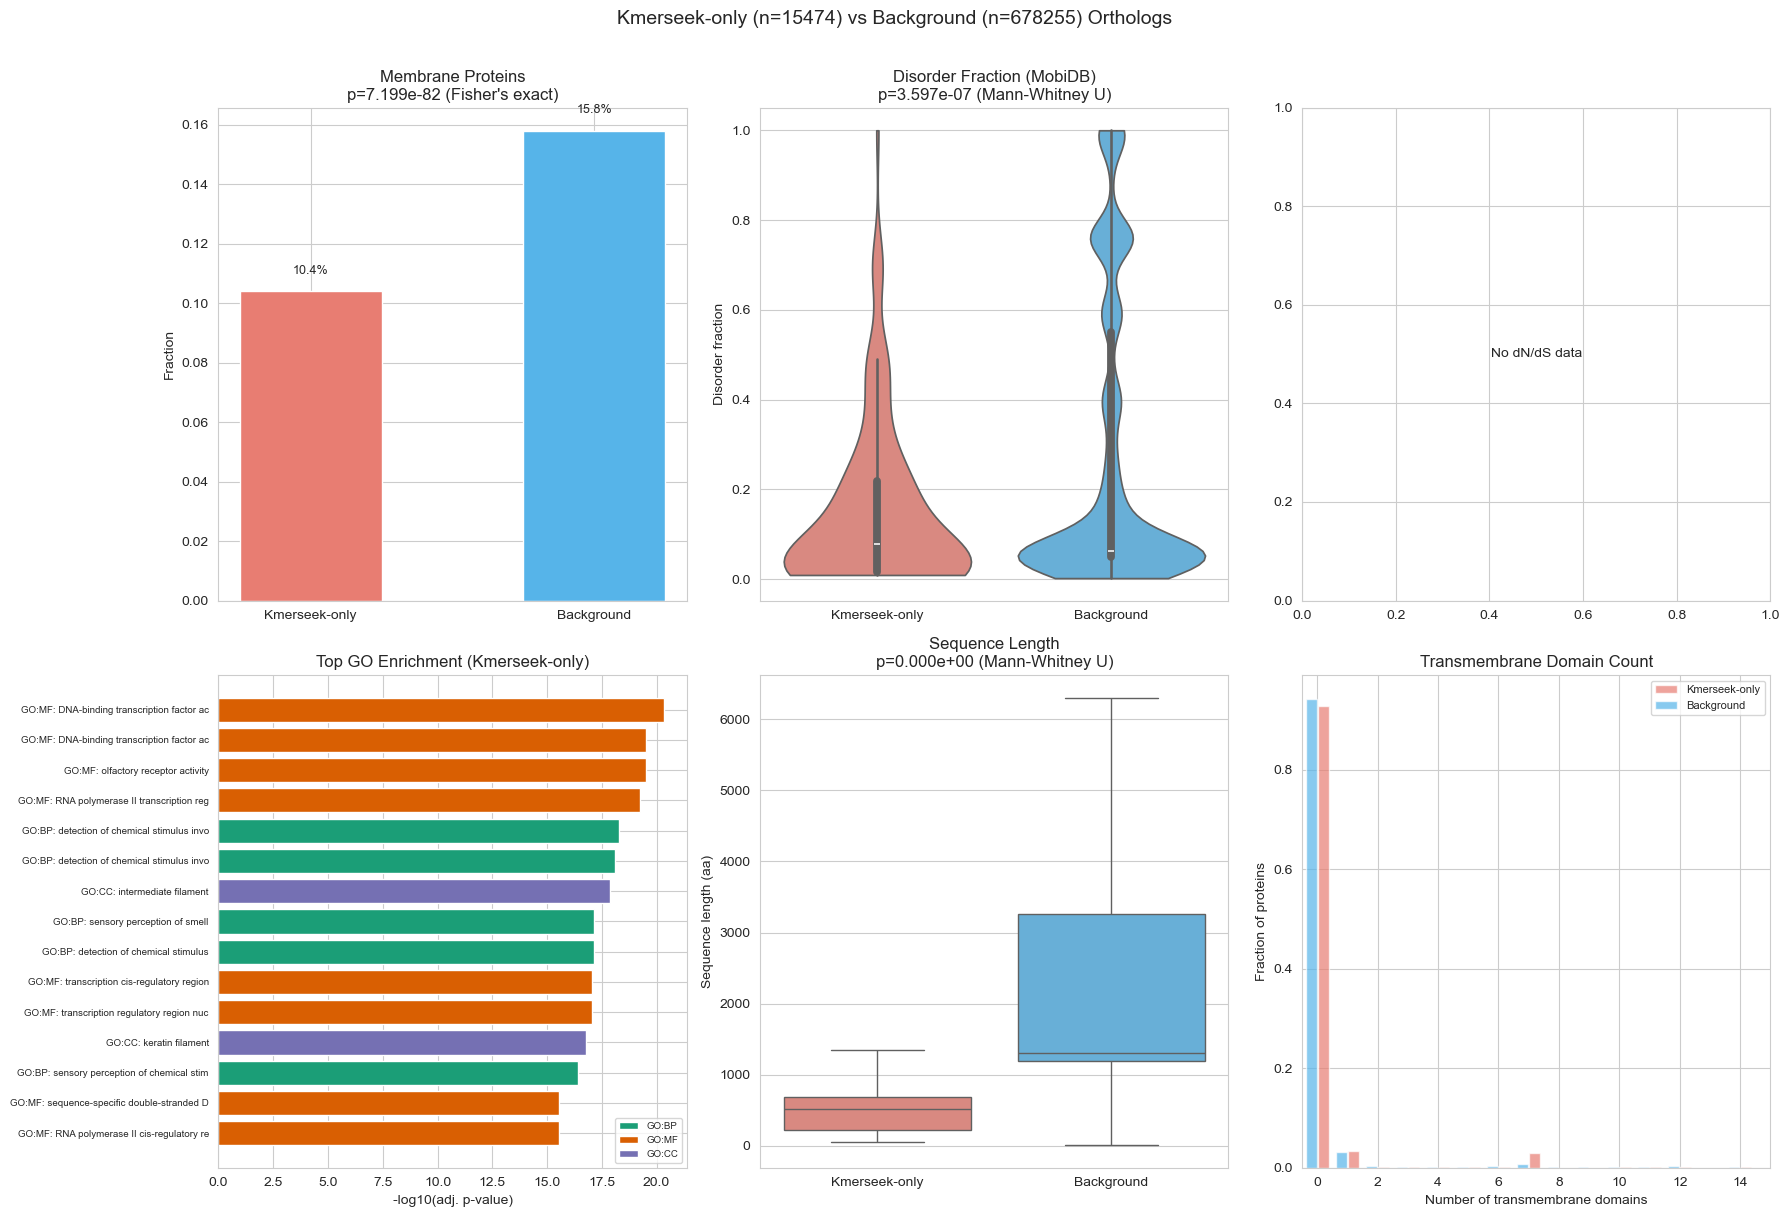

In [21]:
n_ko = len(kmerseek_only_df)
n_bg = len(background_df)

combined = pd.concat(
    [
        kmerseek_only_df.to_pandas().assign(set_label="Kmerseek-only"),
        background_df.to_pandas().assign(set_label="Background"),
    ],
    ignore_index=True,
)

palette = {"Kmerseek-only": "#E87D72", "Background": "#56B4E9"}
order = ["Kmerseek-only", "Background"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f"Kmerseek-only (n={n_ko}) vs Background (n={n_bg}) Orthologs",
    fontsize=14,
    y=1.01,
)

# --- Panel 1: Membrane fraction ---
ax = axes[0, 0]
ko_mem_n = int(kmerseek_only_df["is_membrane"].sum())
bg_mem_n = int(background_df["is_membrane"].sum())
ko_frac = ko_mem_n / n_ko
bg_frac = bg_mem_n / n_bg
_, p_mem = fisher_exact([[ko_mem_n, n_ko - ko_mem_n], [bg_mem_n, n_bg - bg_mem_n]])
bars = ax.bar(order, [ko_frac, bg_frac], color=[palette[k] for k in order], width=0.5)
for bar, val in zip(bars, [ko_frac, bg_frac]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylabel("Fraction")
ax.set_title(f"Membrane Proteins\np={p_mem:.3e} (Fisher's exact)")

# --- Panel 2: Disorder fraction violin ---
ax = axes[0, 1]
dis_data = combined.dropna(subset=["disorder_fraction"])
if len(dis_data) > 10:
    sns.violinplot(
        data=dis_data,
        x="set_label",
        y="disorder_fraction",
        palette=palette,
        order=order,
        ax=ax,
        cut=0,
        inner="box",
    )
    ko_v = dis_data[dis_data["set_label"] == "Kmerseek-only"][
        "disorder_fraction"
    ].values
    bg_v = dis_data[dis_data["set_label"] == "Background"]["disorder_fraction"].values
    p_dis = (
        mannwhitneyu(ko_v, bg_v, alternative="two-sided")[1]
        if (len(ko_v) > 1 and len(bg_v) > 1)
        else float("nan")
    )
    ax.set_title(f"Disorder Fraction (MobiDB)\np={p_dis:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("Disorder fraction")
else:
    ax.text(
        0.5, 0.5, "No MobiDB data", ha="center", va="center", transform=ax.transAxes
    )
    p_dis = float("nan")

# --- Panel 3: dN/dS violin ---
ax = axes[0, 2]
dnds_data = combined.dropna(subset=["dn_ds"])
dnds_data = dnds_data[dnds_data["dn_ds"] < 10]
if len(dnds_data) > 10:
    sns.violinplot(
        data=dnds_data,
        x="set_label",
        y="dn_ds",
        palette=palette,
        order=order,
        ax=ax,
        cut=0,
        inner="box",
    )
    ko_v = dnds_data[dnds_data["set_label"] == "Kmerseek-only"]["dn_ds"].values
    bg_v = dnds_data[dnds_data["set_label"] == "Background"]["dn_ds"].values
    p_dnds = (
        mannwhitneyu(ko_v, bg_v, alternative="two-sided")[1]
        if (len(ko_v) > 1 and len(bg_v) > 1)
        else float("nan")
    )
    ax.set_title(f"dN/dS Ratio\np={p_dnds:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("dN/dS")
else:
    ax.text(0.5, 0.5, "No dN/dS data", ha="center", va="center", transform=ax.transAxes)
    p_dnds = float("nan")

# --- Panel 4: Top GO terms ---
ax = axes[1, 0]
sig_go = (
    go_results[go_results["significant"]].sort_values("p_value").head(15).copy()
    if len(go_results) > 0
    else pd.DataFrame()
)
if len(sig_go) > 0:
    source_colors = {"GO:BP": "#1B9E77", "GO:MF": "#D95F02", "GO:CC": "#7570B3"}
    bar_colors = [source_colors.get(s, "grey") for s in sig_go["source"]]
    ax.barh(range(len(sig_go)), -np.log10(sig_go["p_value"]), color=bar_colors)
    ax.set_yticks(range(len(sig_go)))
    ax.set_yticklabels(
        [f"{row.source}: {row['name'][:35]}" for _, row in sig_go.iterrows()],
        fontsize=7,
    )
    ax.invert_yaxis()
    ax.set_xlabel("-log10(adj. p-value)")
    ax.set_title("Top GO Enrichment (Kmerseek-only)")
    from matplotlib.patches import Patch

    ax.legend(
        handles=[Patch(facecolor=c, label=s) for s, c in source_colors.items()],
        fontsize=7,
        loc="lower right",
    )
else:
    ax.text(
        0.5,
        0.5,
        "No significant GO terms",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
    ax.set_title("Top GO Enrichment (Kmerseek-only)")

# --- Panel 5: Sequence length boxplot ---
ax = axes[1, 1]
len_data = combined.dropna(subset=["seq_length"])
if len(len_data) > 10:
    sns.boxplot(
        data=len_data,
        x="set_label",
        y="seq_length",
        palette=palette,
        order=order,
        ax=ax,
        showfliers=False,
    )
    ko_v = len_data[len_data["set_label"] == "Kmerseek-only"]["seq_length"].values
    bg_v = len_data[len_data["set_label"] == "Background"]["seq_length"].values
    p_len = (
        mannwhitneyu(ko_v, bg_v, alternative="two-sided")[1]
        if (len(ko_v) > 1 and len(bg_v) > 1)
        else float("nan")
    )
    ax.set_title(f"Sequence Length\np={p_len:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("Sequence length (aa)")
else:
    ax.text(
        0.5, 0.5, "No length data", ha="center", va="center", transform=ax.transAxes
    )
    p_len = float("nan")

# --- Panel 6: Transmembrane domain count ---
ax = axes[1, 2]
tm_data = combined.dropna(subset=["n_transmembrane"])
if len(tm_data) > 0:
    for label, color in palette.items():
        sub = tm_data[tm_data["set_label"] == label]
        counts = sub["n_transmembrane"].value_counts().sort_index()
        offset = 0.2 if label == "Kmerseek-only" else -0.2
        ax.bar(
            counts.index + offset,
            counts.values / len(sub),
            alpha=0.7,
            color=color,
            label=label,
            width=0.35,
        )
    ax.set_xlabel("Number of transmembrane domains")
    ax.set_ylabel("Fraction of proteins")
    ax.set_title("Transmembrane Domain Count")
    ax.set_xlim(-0.5, 15)
    ax.legend(fontsize=8)

plt.tight_layout()
fig_path = DATA_DIR / f"{PREFIX}kmerseek_only_characterization.png"
plt.savefig(str(fig_path), dpi=300, bbox_inches="tight")
print(f"Figure saved to {fig_path}")
plt.show()

## Cell 8: Summary Statistics Table

In [22]:
ko_pd = kmerseek_only_df.to_pandas()
bg_pd = background_df.to_pandas()


def safe_mwu(a, b):
    a = [v for v in a if v is not None and not (isinstance(v, float) and np.isnan(v))]
    b = [v for v in b if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    return mannwhitneyu(a, b, alternative="two-sided")[1]


ko_mem_n = int(ko_pd["is_membrane"].sum())
bg_mem_n = int(bg_pd["is_membrane"].sum())
_, p_mem = fisher_exact([[ko_mem_n, n_ko - ko_mem_n], [bg_mem_n, n_bg - bg_mem_n]])

ko_dis_n = int(ko_pd["has_disordered_regions"].sum())
bg_dis_n = int(bg_pd["has_disordered_regions"].sum())
_, p_dis_binary = fisher_exact(
    [[ko_dis_n, n_ko - ko_dis_n], [bg_dis_n, n_bg - bg_dis_n]]
)

ko_mobi = ko_pd["disorder_fraction"].dropna().values
bg_mobi = bg_pd["disorder_fraction"].dropna().values
p_mobi = safe_mwu(ko_mobi, bg_mobi)

ko_dn = ko_pd["dn_ds"].dropna().values
bg_dn = bg_pd["dn_ds"].dropna().values
p_dn = safe_mwu(ko_dn, bg_dn)

ko_ln = ko_pd["seq_length"].dropna().values
bg_ln = bg_pd["seq_length"].dropna().values
p_ln = safe_mwu(ko_ln, bg_ln)

summary_rows = [
    {
        "Feature": "% membrane proteins",
        f"Kmerseek-only (n={n_ko})": f"{100 * ko_mem_n / n_ko:.1f}%",
        f"Background (n={n_bg})": f"{100 * bg_mem_n / n_bg:.1f}%",
        "p-value": f"{p_mem:.3e}",
        "Test": "Fisher's exact",
    },
    {
        "Feature": "% with disordered regions (UniProt)",
        f"Kmerseek-only (n={n_ko})": f"{100 * ko_dis_n / n_ko:.1f}%",
        f"Background (n={n_bg})": f"{100 * bg_dis_n / n_bg:.1f}%",
        "p-value": f"{p_dis_binary:.3e}",
        "Test": "Fisher's exact",
    },
    {
        "Feature": "Median disorder fraction (MobiDB)",
        f"Kmerseek-only (n={n_ko})": (
            f"{np.median(ko_mobi):.3f}" if len(ko_mobi) else "N/A"
        ),
        f"Background (n={n_bg})": (
            f"{np.median(bg_mobi):.3f}" if len(bg_mobi) else "N/A"
        ),
        "p-value": f"{p_mobi:.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median dN/dS",
        f"Kmerseek-only (n={n_ko})": f"{np.median(ko_dn):.4f}" if len(ko_dn) else "N/A",
        f"Background (n={n_bg})": f"{np.median(bg_dn):.4f}" if len(bg_dn) else "N/A",
        "p-value": f"{p_dn:.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median sequence length (aa)",
        f"Kmerseek-only (n={n_ko})": f"{np.median(ko_ln):.0f}" if len(ko_ln) else "N/A",
        f"Background (n={n_bg})": f"{np.median(bg_ln):.0f}" if len(bg_ln) else "N/A",
        "p-value": f"{p_ln:.3e}",
        "Test": "Mann-Whitney U",
    },
]

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_path = DATA_DIR / f"{PREFIX}summary_statistics.csv"
summary_df.to_csv(str(summary_path), index=False)
print(f"\nSaved to {summary_path}")

                            Feature Kmerseek-only (n=15474) Background (n=678255)   p-value           Test
                % membrane proteins                   10.4%                 15.8% 7.199e-82 Fisher's exact
% with disordered regions (UniProt)                   20.0%                 93.4% 0.000e+00 Fisher's exact
  Median disorder fraction (MobiDB)                   0.077                 0.063 3.597e-07 Mann-Whitney U
                       Median dN/dS                     N/A                   N/A       nan Mann-Whitney U
        Median sequence length (aa)                     522                  1301 0.000e+00 Mann-Whitney U

Saved to /Users/olga/data/gencode/results-human-mouse-orthologs/119_summary_statistics.csv


In [23]:
annotation_cols = [
    "human_gene_name",
    "mouse_gene_name",
    "human_protein_id",
    "human_gene_id",
    "uniprot_acc",
    "set_label",
    "poisson_p",
    "seq_length",
    "subcellular_location",
    "is_membrane",
    "is_secreted",
    "is_nuclear",
    "n_transmembrane",
    "n_disordered_regions",
    "has_disordered_regions",
    "disorder_fraction",
    "dn_ds",
    "keywords",
]

combined_ann = pl.concat(
    [
        kmerseek_only_df.select(
            [c for c in annotation_cols if c in kmerseek_only_df.columns]
        ),
        background_df.select(
            [c for c in annotation_cols if c in background_df.columns]
        ),
    ]
)

ann_path = DATA_DIR / f"{PREFIX}annotation_results.csv"
combined_ann.write_csv(str(ann_path))
print(f"Saved {len(combined_ann):,} rows to {ann_path}")
combined_ann.head(5)

Saved 693,729 rows to /Users/olga/data/gencode/results-human-mouse-orthologs/119_annotation_results.csv


human_gene_name,mouse_gene_name,human_protein_id,human_gene_id,uniprot_acc,set_label,poisson_p,seq_length,subcellular_location,is_membrane,is_secreted,is_nuclear,n_transmembrane,n_disordered_regions,has_disordered_regions,disorder_fraction,dn_ds,keywords
str,str,str,str,str,str,f64,i64,str,bool,bool,bool,i64,i64,bool,f64,f64,str
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,null,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,null,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,null,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,null,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,null,"""Glycoprotein; Hydrolase; Membr…"
